In [ ]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/netflix_project'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs(f'{BASE}/outputs', exist_ok=True)

df = pd.read_csv(f'{BASE}/data/processed/ratings_sampled.csv')
movies = pd.read_csv(f'{BASE}/data/processed/movies.csv')

print("Setup complete!")
print(f"Ratings: {df.shape}")
print(f"Movies: {movies.shape}")

Mounted at /content/drive
Setup complete!
Ratings: (18829034, 4)
Movies: (17770, 3)


# 02 - Exploratory Data Analysis
This notebook explores the Netflix Prize dataset to understand
user behaviour, rating patterns, content popularity and sparsity.

## Basic Statistics

In [ ]:
# Cell 2 - basic statistics
print("="*40)
print(f"Total ratings:  {len(df):,}")
print(f"Total users:    {df['user_id'].nunique():,}")
print(f"Total movies:   {df['movie_id'].nunique():,}")
print("="*40)
print(f"\nRating distribution:")
print(df['rating'].value_counts().sort_index())

Total ratings:  18,829,034
Total users:    176,959
Total movies:   17,767

Rating distribution:
rating
1     921051
2    1764630
3    4666015
4    6328152
5    5149186
Name: count, dtype: int64


## Rating Distribution

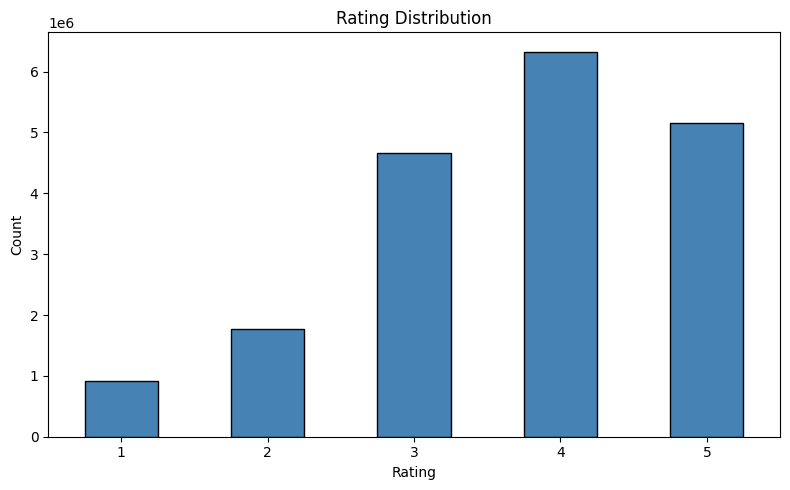

Saved!


In [ ]:
# Cell 3 - rating distribution plot
plt.figure(figsize=(8,5))
df['rating'].value_counts().sort_index().plot(kind='bar',
                                               color='steelblue',
                                               edgecolor='black')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/rating_distribution.png')
plt.show()
print("Saved!")

## User Activity Analysis

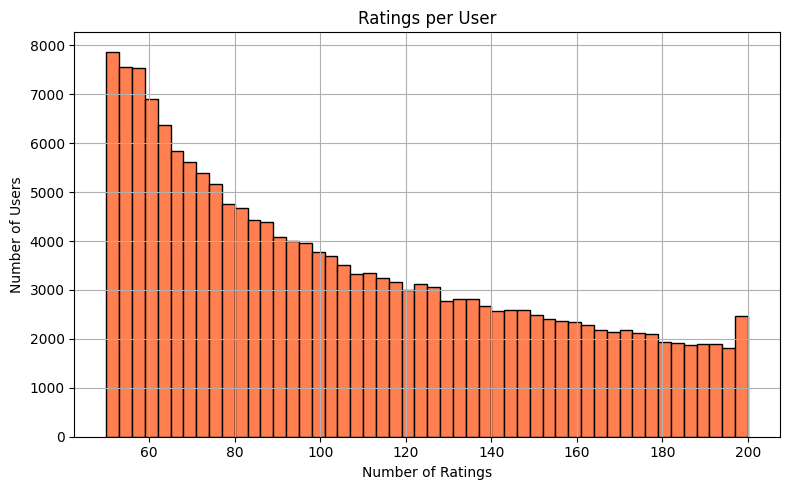

count    176959.000000
mean        106.403370
std          42.823422
min          50.000000
25%          69.000000
50%          97.000000
75%         139.000000
max         200.000000
Name: rating, dtype: float64


In [ ]:
# Cell 4 - ratings per user
ratings_per_user = df.groupby('user_id')['rating'].count()

plt.figure(figsize=(8,5))
ratings_per_user.hist(bins=50, color='coral', edgecolor='black')
plt.title('Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/ratings_per_user.png')
plt.show()
print(ratings_per_user.describe())

## Most Popular Movies

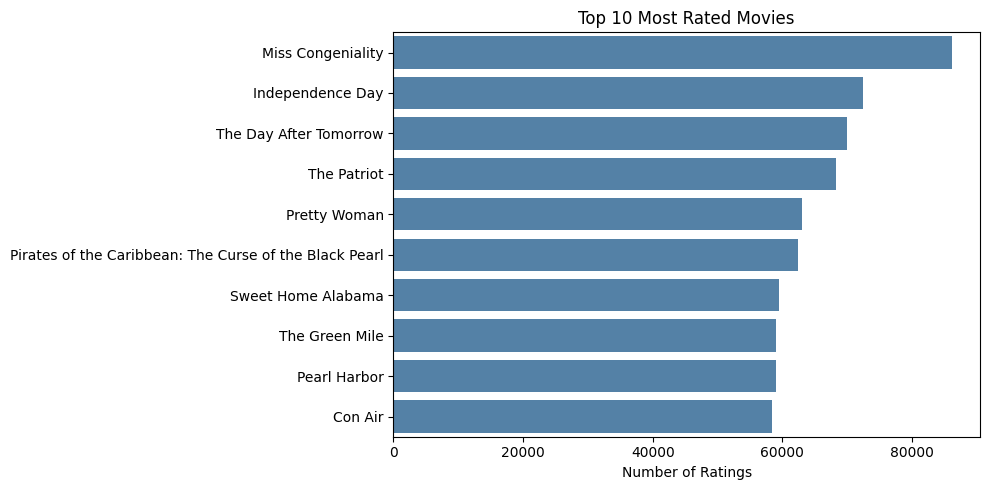

In [ ]:
# Cell 5 - most rated movies
top_movies = df.groupby('movie_id')['rating'].count()\
               .sort_values(ascending=False).head(10).reset_index()
top_movies = top_movies.merge(movies[['movie_id','title']], on='movie_id')

plt.figure(figsize=(10,5))
sns.barplot(data=top_movies, x='rating', y='title', color='steelblue')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/top_movies.png')
plt.show()

## Highest Rated Movies
Minimum 1000 ratings filter applied to avoid obscure movies
with only a few perfect ratings skewing the results.

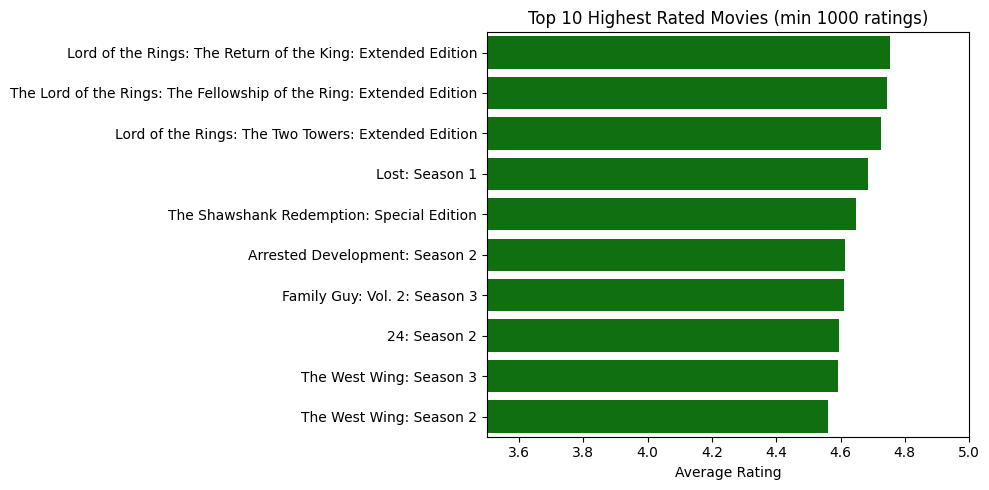

In [ ]:
# Cell 6 - highest rated movies (min 1000 ratings)
movie_stats = df.groupby('movie_id')['rating']\
                .agg(['mean','count']).reset_index()
movie_stats.columns = ['movie_id','avg_rating','num_ratings']

popular = movie_stats[movie_stats['num_ratings'] >= 1000]
top_avg = popular.sort_values('avg_rating', ascending=False).head(10)
top_avg = top_avg.merge(movies[['movie_id','title']], on='movie_id')

plt.figure(figsize=(10,5))
sns.barplot(data=top_avg, x='avg_rating', y='title', color='green')
plt.title('Top 10 Highest Rated Movies (min 1000 ratings)')
plt.xlabel('Average Rating')
plt.ylabel('')
plt.xlim(3.5, 5)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/avg_rating_movies.png')
plt.show()

## Sparsity Analysis

In [ ]:
# Cell 7 - sparsity analysis
num_users = df['user_id'].nunique()
num_movies = df['movie_id'].nunique()
num_ratings = len(df)

sparsity = 1 - (num_ratings / (num_users * num_movies))

print("="*45)
print(f"Matrix size:            {num_users:,} x {num_movies:,}")
print(f"Total possible ratings: {num_users * num_movies:,}")
print(f"Actual ratings:         {num_ratings:,}")
print(f"Sparsity:               {sparsity:.4%}")
print("="*45)

Matrix size:            176,959 x 17,767
Total possible ratings: 3,144,030,553
Actual ratings:         18,829,034
Sparsity:               99.4011%


## Ratings per Movie Distribution

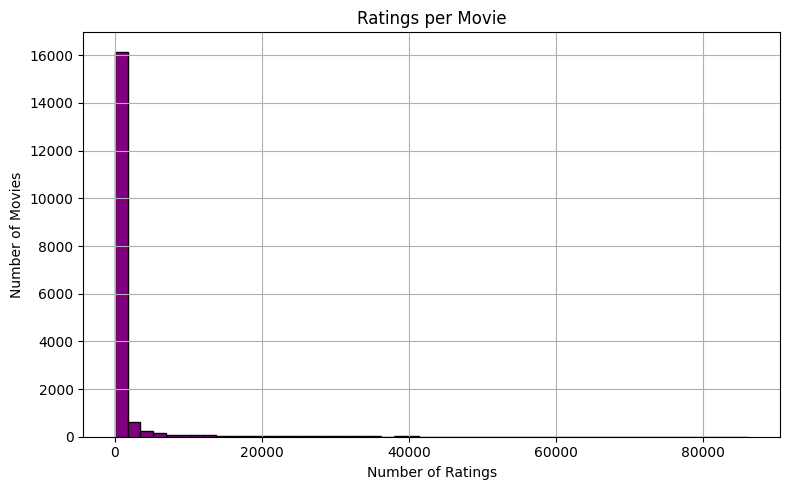

count    17767.000000
mean      1059.775651
std       4354.471200
min          1.000000
25%         36.000000
50%         92.000000
75%        344.000000
max      86181.000000
Name: rating, dtype: float64


In [ ]:
# Cell 8 - ratings per movie
ratings_per_movie = df.groupby('movie_id')['rating'].count()

plt.figure(figsize=(8,5))
ratings_per_movie.hist(bins=50, color='purple', edgecolor='black')
plt.title('Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/ratings_per_movie.png')
plt.show()
print(ratings_per_movie.describe())

## Key Insights
- Dataset: 18.8M ratings, 176,959 users, 17,767 movies
- Sparsity: 99.4% — only 0.6% of all possible ratings exist
- Most common ratings are 4 and 3 — users rate movies they enjoyed
- Rating 1 is least common — users rarely rate movies they hated
- Miss Congeniality is the most rated movie in our sample
- Small number of movies receive disproportionately large ratings
- Average user rated 106 movies (median: 97)
- High sparsity makes collaborative filtering both challenging and necessary